# Domain Adaptation на WB датасете


In [1]:
import copy
import json
import os
import random
import re
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_curve, auc as sk_auc
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from scipy.special import softmax as sp_softmax

import torch
import evaluate
from datasets import Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments, logging as hf_logging

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

hf_logging.set_verbosity_error()
warnings.filterwarnings('ignore', category=ConvergenceWarning)

BASE_DIR = Path('/Users/yana/Курсовая 3 курс')
os.chdir(BASE_DIR)
print('Рабочая папка:', BASE_DIR)


Рабочая папка: /Users/yana/Курсовая 3 курс


## Загрузка модели, обученной на MAiDE-up hotel reviews в первом ноутбуке


In [2]:
rubert_path = BASE_DIR / 'models' / 'rubert'
if not rubert_path.exists():
    raise FileNotFoundError('Не найдена models/rubert. Сначала запусти 1_training_hotel_reviews.ipynb')

tokenizer = AutoTokenizer.from_pretrained(rubert_path)
model_s1 = AutoModelForSequenceClassification.from_pretrained(rubert_path, num_labels=2)
model_s1.eval()

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(83828, 312, padding_idx=0)
      (position_embeddings): Embedding(2048, 312)
      (token_type_embeddings): Embedding(2, 312)
      (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-2): 3 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=312, out_features=312, bias=True)
              (key): Linear(in_features=312, out_features=312, bias=True)
              (value): Linear(in_features=312, out_features=312, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=312, out_features=312, bias=True)
              (LayerNorm): LayerNorm((312,), eps=1e-12, 

## OOD тест


In [3]:
OOD_FAKES = [
    'Брала украшение маме на юбилей. Смотрится аккуратно, застёжка нормальная, но коробочка была чуть помята. В целом носить можно, выглядит дороже своей цены.',
    'Велосипед сыну взяли на лето. Сборка заняла около часа, один болт пришлось подтянуть. Катается нормально, для двора вариант хороший.',
    'Скатерть брала на праздничный стол. Цвет немного светлее, чем на фото, но ткань плотная и после стирки не перекосилась.',
    'Парфюм заказала подруге. Запах приятный, не резкий, держится несколько часов. Упаковка целая, хотя плёнка была чуть замята.',
    'Коврик в прихожую подошёл по размеру. Не скользит, чистится обычной щёткой. После недели использования края немного расправились.',
    'Посуда нормальная для такой цены. Пользуемся второй месяц, рисунок не облез, но одна тарелка пришла с маленькой точкой на глазури.',
    'Аквариум брали ребёнку. Фильтр работает тихо, стекло без сколов. Инструкция короткая, пришлось смотреть сборку отдельно.',
    'Шторы повесила сама, ткань плотная. Блэкаут работает, утром темнее. По ширине хотелось бы чуть больше, но в целом подошли.',
]

OOD_REALS_MANUAL = [
    'Размер подошёл, но ткань тоньше чем ожидала. После стирки форму не потеряла, носить можно.',
    'Пришло быстро, упаковка целая. Цвет на фото немного ярче, в жизни спокойнее.',
    'Для своей цены нормально, но запах пластика держался пару дней.',
    'Покупала ребёнку, понравилось. Один шов не очень ровный, но не критично.',
]


## Загрузка WB-датасета


In [4]:
DATASET_PATH = BASE_DIR / 'paired_wb_fake.csv'

dataset_df = pd.read_csv(DATASET_PATH)
dataset_df['text'] = dataset_df['text'].astype(str).str.strip()
dataset_df['is_fake'] = dataset_df['is_fake'].astype(int)

if 'pair_id' not in dataset_df.columns:
    raise ValueError('В датасете нет pair_id. Пересобери CSV через исправленный ноутбук 2.')

dataset_df['text_len'] = dataset_df['text'].str.len()
dataset_df['word_count'] = dataset_df['text'].str.split().str.len()
dataset_df = dataset_df[
    (dataset_df['word_count'] >= 8) &
    (dataset_df['word_count'] <= 90)
].drop_duplicates(subset=['text']).reset_index(drop=True)

pair_counts = dataset_df.groupby('pair_id')['is_fake'].nunique()
complete_pair_ids = pair_counts[pair_counts == 2].index
dataset_df = dataset_df[dataset_df['pair_id'].isin(complete_pair_ids)].reset_index(drop=True)

print('После фильтрации:', len(dataset_df))
print(dataset_df['is_fake'].value_counts().rename({0: 'Real', 1: 'Fake'}))
print(dataset_df.groupby('is_fake')[['text_len', 'word_count']].mean().round(2))


После фильтрации: 298
is_fake
Fake    149
Real    149
Name: count, dtype: int64
         text_len  word_count
is_fake                      
0          226.26       35.16
1          315.46       47.68


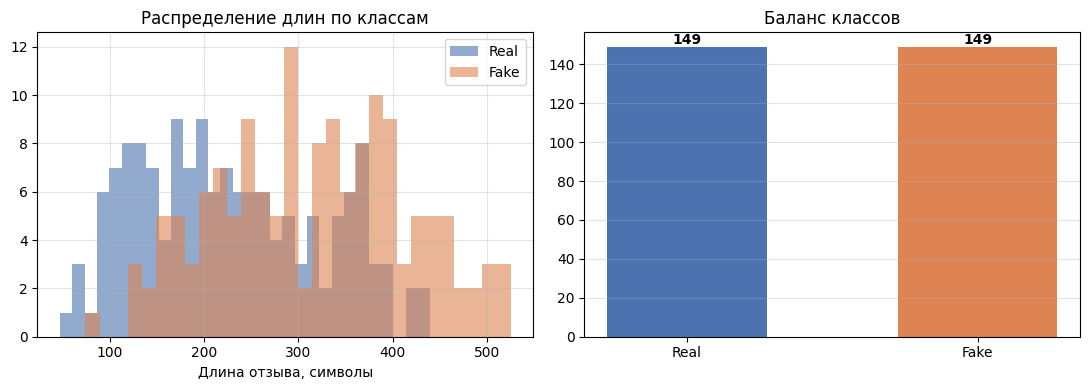

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for label, name, color in [(0, 'Real', '#4C72B0'), (1, 'Fake', '#DD8452')]:
    lengths = dataset_df[dataset_df['is_fake'] == label]['text_len']
    axes[0].hist(lengths, bins=30, alpha=0.6, label=name, color=color)
axes[0].set_xlabel('Длина отзыва, символы')
axes[0].set_title('Распределение длин по классам')
axes[0].legend(); axes[0].grid(alpha=0.35)

counts = dataset_df['is_fake'].value_counts().sort_index()
axes[1].bar(['Real', 'Fake'], counts.values, color=['#4C72B0', '#DD8452'], width=0.55)
for i, v in enumerate(counts.values):
    axes[1].text(i, v + max(counts.values) * 0.01, str(v), ha='center', fontweight='bold')
axes[1].set_title('Баланс классов')
axes[1].grid(axis='y', alpha=0.35)
plt.tight_layout(); plt.show()


## Group split train / validation / test

In [6]:
def grouped_train_val_test_split(df, group_col='pair_id', seed=SEED):
    gss_1 = GroupShuffleSplit(n_splits=1, test_size=0.40, random_state=seed)
    train_idx, tmp_idx = next(gss_1.split(df, df['is_fake'], groups=df[group_col]))
    train_df = df.iloc[train_idx].reset_index(drop=True)
    tmp_df = df.iloc[tmp_idx].reset_index(drop=True)

    gss_2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_rel_idx, test_rel_idx = next(gss_2.split(tmp_df, tmp_df['is_fake'], groups=tmp_df[group_col]))
    val_df = tmp_df.iloc[val_rel_idx].reset_index(drop=True)
    test_df = tmp_df.iloc[test_rel_idx].reset_index(drop=True)

    assert not (set(train_df[group_col]) & set(val_df[group_col]))
    assert not (set(train_df[group_col]) & set(test_df[group_col]))
    assert not (set(val_df[group_col]) & set(test_df[group_col]))
    return train_df, val_df, test_df

train_df, val_df, test_df = grouped_train_val_test_split(dataset_df)

print(f"{'Split':12s} {'N':>5s} {'real':>5s} {'fake':>5s}")
print('-' * 35)
for name, split in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    f = int(split['is_fake'].sum())
    print(f'{name:12s} {len(split):5d} {len(split)-f:5d} {f:5d}')

X_tr2, y_tr2 = train_df['text'].tolist(), train_df['is_fake'].tolist()
X_val2, y_val2 = val_df['text'].tolist(), val_df['is_fake'].tolist()
X_test2, y_test2 = test_df['text'].tolist(), test_df['is_fake'].tolist()


Split            N  real  fake
-----------------------------------
Train          178    89    89
Validation      60    30    30
Test            60    30    30


## Feature-based baseline

Если этот baseline даёт почти идеальный результат, значит в датасете всё ещё остались поверхностные сигналы.


In [7]:
TEMPLATE_WORDS = [
    'рекомендую', 'советую', 'отлично', 'отличный', 'отличная',
    'превосходно', 'замечательно', 'великолепно', 'шикарно',
    'всем', 'однозначно', 'качество', 'довольна', 'доволен',
    'восторг', 'понравилось', 'понравился', 'буду брать', 'заказывала'
]
NEGATIVE_MARKERS = [
    ' но ', 'однако', 'зато', 'хотя', 'жаль', 'к сожалению',
    'минус', 'недостаток', 'плохо', 'не понрав', 'разочар',
    'проблема', 'брак', 'дефект', 'сломался', 'порвался',
    'не соответствует', 'не подош', 'маловат', 'великоват'
]


def extract_features(text):
    t = f' {text.lower()} '
    words = t.split()
    sentences = [s for s in re.split(r'[.!?]', t) if s.strip()]
    return [
        len(text),
        len(words),
        text.count('!'),
        text.count('?'),
        sum(1 for c in text if c.isupper()) / max(len(text), 1),
        sum(1 for w in TEMPLATE_WORDS if w in t),
        sum(1 for m in NEGATIVE_MARKERS if m in t),
        int(bool(re.search(r'\d+', text))),
        int(bool(re.search(r'\b[smlxXSML]{1,3}\b|\d{2,3}\s*(см|мм|кг|г\b)', text))),
        int(bool(re.search(r'черн|бел|красн|син|зелен|сер|бежев|розов', t))),
        len(sentences),
        np.mean([len(w) for w in words]) if words else 0,
    ]

feat_names = [
    'text_length', 'word_count', 'exclamation_count', 'question_marks',
    'caps_ratio', 'template_word_count', 'negative_marker_count',
    'has_numbers', 'has_size', 'has_color', 'sentence_count', 'avg_word_length'
]

feat_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')),
])
feat_pipe.fit(np.array([extract_features(t) for t in X_tr2]), y_tr2)
preds_feat = feat_pipe.predict(np.array([extract_features(t) for t in X_test2]))

print('── Feature-based baseline ──')
print(classification_report(y_test2, preds_feat, digits=4, target_names=['Real', 'Fake']))
print(f'F1: {f1_score(y_test2, preds_feat):.4f}')

coefs = feat_pipe.named_steps['clf'].coef_[0]
for i in np.argsort(np.abs(coefs))[::-1][:6]:
    direction = '→ Fake' if coefs[i] > 0 else '→ Real'
    print(f'{feat_names[i]:24s}: {coefs[i]:+.3f} {direction}')


── Feature-based baseline ──
              precision    recall  f1-score   support

        Real     0.9167    0.7333    0.8148        30
        Fake     0.7778    0.9333    0.8485        30

    accuracy                         0.8333        60
   macro avg     0.8472    0.8333    0.8316        60
weighted avg     0.8472    0.8333    0.8316        60

F1: 0.8485
exclamation_count       : -2.236 → Real
question_marks          : -1.487 → Real
text_length             : +1.075 → Fake
negative_marker_count   : +0.661 → Fake
has_numbers             : -0.500 → Real
template_word_count     : -0.308 → Real


In [8]:
ood_real = OOD_REALS_MANUAL.copy()
extra_real = [t for t, y in zip(X_test2, y_test2) if y == 0][:max(0, 8 - len(ood_real))]
ood_real.extend(extra_real)
OOD_REALS = ood_real[:8]

ood_all = OOD_FAKES + OOD_REALS
ood_labels = [1] * len(OOD_FAKES) + [0] * len(OOD_REALS)
preds_ood_feat = feat_pipe.predict(np.array([extract_features(t) for t in ood_all]))

print('OOD-тест — Feature-based baseline')
print(classification_report(ood_labels, preds_ood_feat, target_names=['Real', 'Fake'], zero_division=0))
print(f'OOD F1: {f1_score(ood_labels, preds_ood_feat, zero_division=0):.4f}')


OOD-тест — Feature-based baseline
              precision    recall  f1-score   support

        Real       0.47      0.88      0.61         8
        Fake       0.00      0.00      0.00         8

    accuracy                           0.44        16
   macro avg       0.23      0.44      0.30        16
weighted avg       0.23      0.44      0.30        16

OOD F1: 0.0000


## Токенизация


In [9]:
def make_da_dataset(texts, labels):
    df_tmp = pd.DataFrame({'text': texts, 'label': labels})
    ds = Dataset.from_pandas(df_tmp.reset_index(drop=True))
    ds = ds.map(
        lambda b: tokenizer(b['text'], truncation=True, padding='max_length', max_length=256),
        batched=True,
    )
    ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
    return ds

train_da = make_da_dataset(X_tr2, y_tr2)
val_da = make_da_dataset(X_val2, y_val2)
test_da = make_da_dataset(X_test2, y_test2)


Map:   0%|          | 0/178 [00:00<?, ? examples/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]


## Взвешенный Trainer и подбор threshold

На малом WB-датасете Stage 1 модель может быть сильно смещена к одному классу. Поэтому для нейросетевых моделей используем class-weighted loss и подбираем порог классификации на validation split.


In [10]:

def compute_balanced_class_weights(labels):
    labels = np.asarray(labels, dtype=int)
    counts = np.bincount(labels, minlength=2)
    total = counts.sum()
    weights = total / (2 * np.maximum(counts, 1))
    return torch.tensor(weights, dtype=torch.float32)

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels', None)
        if labels is None:
            labels = inputs.pop('label')
        outputs = model(**inputs)
        logits = outputs.logits
        weight = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss = torch.nn.CrossEntropyLoss(weight=weight)(logits.view(-1, model.config.num_labels), labels.view(-1).long())
        return (loss, outputs) if return_outputs else loss

def tune_threshold(y_true, probs, low=0.05, high=0.95, steps=181):
    y_true = np.asarray(y_true, dtype=int)
    probs = np.asarray(probs, dtype=float)
    best_t, best_f1 = 0.5, -1
    for t in np.linspace(low, high, steps):
        f1 = f1_score(y_true, (probs >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return float(best_t), float(best_f1)

def probs_from_trainer(trainer, dataset):
    pred = trainer.predict(dataset)
    probs = sp_softmax(pred.predictions, axis=1)[:, 1]
    return probs

def predict_with_model(model, texts, batch_size=16):
    model.eval()
    device = next(model.parameters()).device
    probs, preds = [], []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inp = tokenizer(batch, return_tensors='pt', truncation=True, padding='max_length', max_length=256)
        inp = {k: v.to(device) for k, v in inp.items()}
        with torch.no_grad():
            logits = model(**inp).logits.cpu().numpy()
        p = sp_softmax(logits, axis=1)[:, 1]
        probs.extend(p.tolist())
        preds.extend((p >= 0.5).astype(int).tolist())
    return np.array(preds), np.array(probs)


## Fine-tuning RuBERT Stage 2

In [11]:
model_da = copy.deepcopy(model_s1)

# Сбрасываем только классификационную голову, encoder остаётся от Stage 1.
hidden_size = model_da.config.hidden_size
model_da.classifier = torch.nn.Linear(hidden_size, 2)
model_da.config.num_labels = 2

_metric_f1 = evaluate.load('f1')
_metric_acc = evaluate.load('accuracy')

def compute_metrics_da(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': _metric_acc.compute(predictions=preds, references=labels)['accuracy'],
        'f1': _metric_f1.compute(predictions=preds, references=labels, average='binary')['f1'],
    }

class_weights_da = compute_balanced_class_weights(y_tr2)
print('Class weights Stage 2:', class_weights_da.tolist())

args_da = TrainingArguments(
    output_dir='rubert_stage2',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=20,
    report_to='none',
    seed=SEED,
    data_seed=SEED,
    dataloader_pin_memory=False,
)

trainer_da = WeightedTrainer(
    model=model_da,
    args=args_da,
    train_dataset=train_da,
    eval_dataset=val_da,
    compute_metrics=compute_metrics_da,
    class_weights=class_weights_da,
)

trainer_da.train()


Class weights Stage 2: [1.0, 1.0]
{'loss': '0.7523', 'grad_norm': '3.196', 'learning_rate': '1.864e-05', 'epoch': '0.8696'}
{'eval_loss': '0.6937', 'eval_accuracy': '0.5333', 'eval_f1': '0.6585', 'eval_runtime': '0.245', 'eval_samples_per_second': '244.9', 'eval_steps_per_second': '16.32', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.6684', 'grad_norm': '3.152', 'learning_rate': '1.476e-05', 'epoch': '1.739'}
{'eval_loss': '0.6206', 'eval_accuracy': '0.7', 'eval_f1': '0.7', 'eval_runtime': '0.196', 'eval_samples_per_second': '306.1', 'eval_steps_per_second': '20.41', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.5739', 'grad_norm': '3.671', 'learning_rate': '1.087e-05', 'epoch': '2.609'}
{'eval_loss': '0.552', 'eval_accuracy': '0.7833', 'eval_f1': '0.8', 'eval_runtime': '0.2076', 'eval_samples_per_second': '289', 'eval_steps_per_second': '19.27', 'epoch': '3'}


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.4839', 'grad_norm': '3.235', 'learning_rate': '3.107e-06', 'epoch': '4.348'}
{'eval_loss': '0.4954', 'eval_accuracy': '0.8167', 'eval_f1': '0.8308', 'eval_runtime': '0.1799', 'eval_samples_per_second': '333.6', 'eval_steps_per_second': '22.24', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '14.98', 'train_samples_per_second': '59.42', 'train_steps_per_second': '7.677', 'train_loss': '0.5845', 'epoch': '5'}


TrainOutput(global_step=115, training_loss=0.5845146345055622, metrics={'train_runtime': 14.9792, 'train_samples_per_second': 59.416, 'train_steps_per_second': 7.677, 'train_loss': 0.5845146345055622, 'epoch': 5.0})

## Оценка моделей на одном test split


In [12]:
val_probs_da = probs_from_trainer(trainer_da, val_da)
best_t_da, val_f1_da = tune_threshold(y_val2, val_probs_da)
print(f'Stage 2 threshold по validation: t={best_t_da:.3f}, val F1={val_f1_da:.4f}')

pred_da = trainer_da.predict(test_da)
probs_da = sp_softmax(pred_da.predictions, axis=1)[:, 1]
preds_da = (probs_da >= best_t_da).astype(int)

preds_s1_raw, probs_s1 = predict_with_model(model_s1, X_test2)
preds_s1 = preds_s1_raw

print('RuBERT + WB adaptation, tuned threshold')
print(classification_report(y_test2, preds_da, digits=4, target_names=['Real', 'Fake']))

print('RuBERT Stage MAiDE-up only на том же WB test, threshold=0.5')
print(classification_report(y_test2, preds_s1, digits=4, target_names=['Real', 'Fake'], zero_division=0))


Stage 2 threshold по validation: t=0.460, val F1=0.8529
RuBERT + WB adaptation, tuned threshold
              precision    recall  f1-score   support

        Real     0.9565    0.7333    0.8302        30
        Fake     0.7838    0.9667    0.8657        30

    accuracy                         0.8500        60
   macro avg     0.8702    0.8500    0.8479        60
weighted avg     0.8702    0.8500    0.8479        60

RuBERT Stage MAiDE-up only на том же WB test, threshold=0.5
              precision    recall  f1-score   support

        Real     0.5000    1.0000    0.6667        30
        Fake     0.0000    0.0000    0.0000        30

    accuracy                         0.5000        60
   macro avg     0.2500    0.5000    0.3333        60
weighted avg     0.2500    0.5000    0.3333        60



In [13]:
tfidf_wb = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.90, sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')),
])
tfidf_wb.fit(X_tr2, y_tr2)
preds_lr_wb = tfidf_wb.predict(X_test2)
probs_lr_wb = tfidf_wb.predict_proba(X_test2)[:, 1]

print('TF-IDF + LogReg baseline')
print(classification_report(y_test2, preds_lr_wb, digits=4, target_names=['Real', 'Fake']))
print(f'F1: {f1_score(y_test2, preds_lr_wb):.4f}')


TF-IDF + LogReg baseline
              precision    recall  f1-score   support

        Real     0.9667    0.9667    0.9667        30
        Fake     0.9667    0.9667    0.9667        30

    accuracy                         0.9667        60
   macro avg     0.9667    0.9667    0.9667        60
weighted avg     0.9667    0.9667    0.9667        60

F1: 0.9667


## RuBERT без hotel initialization

In [14]:
MODEL_NAME_S = 'cointegrated/rubert-tiny2'
model_scratch = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_S, num_labels=2)

_metric_f1_s = evaluate.load('f1')
_metric_acc_s = evaluate.load('accuracy')

def compute_metrics_scratch(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': _metric_acc_s.compute(predictions=preds, references=labels)['accuracy'],
        'f1': _metric_f1_s.compute(predictions=preds, references=labels, average='binary')['f1'],
    }

args_scratch = TrainingArguments(
    output_dir='rubert_scratch',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=20,
    report_to='none',
    seed=SEED,
    data_seed=SEED,
    dataloader_pin_memory=False,
)

class_weights_scratch = compute_balanced_class_weights(y_tr2)
print('Class weights scratch:', class_weights_scratch.tolist())

trainer_scratch = WeightedTrainer(
    model=model_scratch,
    args=args_scratch,
    train_dataset=train_da,
    eval_dataset=val_da,
    compute_metrics=compute_metrics_scratch,
    class_weights=class_weights_scratch,
)

trainer_scratch.train()

val_probs_scratch = probs_from_trainer(trainer_scratch, val_da)
best_t_scratch, val_f1_scratch = tune_threshold(y_val2, val_probs_scratch)
print(f'Scratch threshold по validation: t={best_t_scratch:.3f}, val F1={val_f1_scratch:.4f}')

pred_scratch = trainer_scratch.predict(test_da)
probs_scratch = sp_softmax(pred_scratch.predictions, axis=1)[:, 1]
preds_scratch = (probs_scratch >= best_t_scratch).astype(int)

print('RuBERT scratch на WB test, tuned threshold')
print(classification_report(y_test2, preds_scratch, digits=4, target_names=['Real', 'Fake']))


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

Class weights scratch: [1.0, 1.0]
{'loss': '0.6819', 'grad_norm': '1.261', 'learning_rate': '1.613e-05', 'epoch': '0.8696'}
{'eval_loss': '0.6653', 'eval_accuracy': '0.65', 'eval_f1': '0.7407', 'eval_runtime': '0.205', 'eval_samples_per_second': '292.7', 'eval_steps_per_second': '19.51', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.6622', 'grad_norm': '1.038', 'learning_rate': '9.677e-06', 'epoch': '1.739'}
{'eval_loss': '0.6402', 'eval_accuracy': '0.8167', 'eval_f1': '0.8451', 'eval_runtime': '0.2215', 'eval_samples_per_second': '270.9', 'eval_steps_per_second': '18.06', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.6299', 'grad_norm': '1.484', 'learning_rate': '3.226e-06', 'epoch': '2.609'}
{'eval_loss': '0.6284', 'eval_accuracy': '0.85', 'eval_f1': '0.8696', 'eval_runtime': '0.2507', 'eval_samples_per_second': '239.4', 'eval_steps_per_second': '15.96', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '9.251', 'train_samples_per_second': '57.73', 'train_steps_per_second': '7.459', 'train_loss': '0.6526', 'epoch': '3'}
Scratch threshold по validation: t=0.520, val F1=0.9355
RuBERT scratch на WB test, tuned threshold
              precision    recall  f1-score   support

        Real     0.9667    0.9667    0.9667        30
        Fake     0.9667    0.9667    0.9667        30

    accuracy                         0.9667        60
   macro avg     0.9667    0.9667    0.9667        60
weighted avg     0.9667    0.9667    0.9667        60



## Итоговая таблица


In [15]:
summary = pd.DataFrame([
    {'Модель': 'Feature-based baseline', 'F1': f1_score(y_test2, preds_feat), 'Accuracy': accuracy_score(y_test2, preds_feat)},
    {'Модель': 'TF-IDF + LogReg', 'F1': f1_score(y_test2, preds_lr_wb), 'Accuracy': accuracy_score(y_test2, preds_lr_wb)},
    {'Модель': 'RuBERT Stage 1 (MAiDE-up only)', 'F1': f1_score(y_test2, preds_s1, zero_division=0), 'Accuracy': accuracy_score(y_test2, preds_s1)},
    {'Модель': 'RuBERT scratch (WB only, tuned t)', 'F1': f1_score(y_test2, preds_scratch), 'Accuracy': accuracy_score(y_test2, preds_scratch)},
    {'Модель': 'RuBERT Stage 2 (reset head + WB, tuned t)', 'F1': f1_score(y_test2, preds_da), 'Accuracy': accuracy_score(y_test2, preds_da)},
]).sort_values('F1', ascending=False).reset_index(drop=True)

display(summary.style.format({'F1': '{:.4f}', 'Accuracy': '{:.4f}'}).background_gradient(subset=['F1', 'Accuracy'], cmap='Greens'))

final_model_name = summary.loc[0, 'Модель']
print(f'Финальная модель по тест F1: {final_model_name}')
print('Интерпретация:')

stage2_f1 = f1_score(y_test2, preds_da)
scratch_f1 = f1_score(y_test2, preds_scratch)
tfidf_f1 = f1_score(y_test2, preds_lr_wb)
feat_f1 = f1_score(y_test2, preds_feat)

,Модель,F1,Accuracy
0,TF-IDF + LogReg,0.9667,0.9667
1,"RuBERT scratch (WB only, tuned t)",0.9667,0.9667
2,"RuBERT Stage 2 (reset head + WB, tuned t)",0.8657,0.8500
3,Feature-based baseline,0.8485,0.8333
4,RuBERT Stage 1 (MAiDE-up only),0.0000,0.5000


Финальная модель по тест F1: TF-IDF + LogReg
Интерпретация:


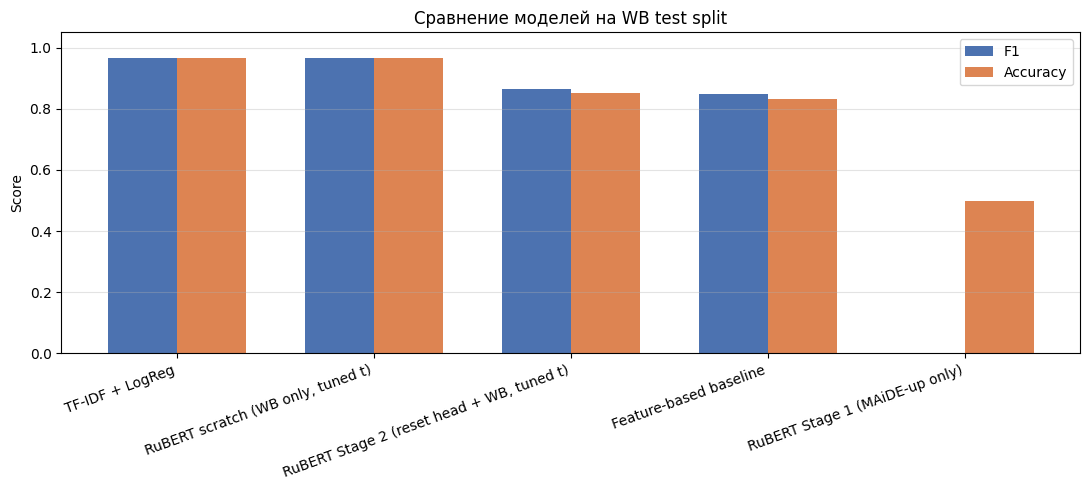

In [16]:
labels = summary['Модель']
x = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, summary['F1'], w, label='F1', color='#4C72B0')
ax.bar(x + w/2, summary['Accuracy'], w, label='Accuracy', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Сравнение моделей на WB test split')
ax.legend(); ax.grid(axis='y', alpha=0.35)
plt.tight_layout(); plt.show()


## OOD-тест финальных моделей

In [17]:
ood_all = OOD_FAKES + OOD_REALS
ood_labels = np.array([1] * len(OOD_FAKES) + [0] * len(OOD_REALS))

ood_rows = []

def add_ood_result(name, probs, threshold):
    preds = (np.asarray(probs) >= threshold).astype(int)
    ood_rows.append({
        'Модель': name,
        'threshold': threshold,
        'OOD F1': f1_score(ood_labels, preds, zero_division=0),
        'OOD Accuracy': accuracy_score(ood_labels, preds),
        'Fake recall': ((preds[:len(OOD_FAKES)] == 1).mean()),
        'Real recall': ((preds[len(OOD_FAKES):] == 0).mean()),
    })
    return preds

# Feature-based baseline
ood_probs_feat = feat_pipe.predict_proba(np.array([extract_features(t) for t in ood_all]))[:, 1]
preds_ood_feat = add_ood_result('Feature-based baseline', ood_probs_feat, 0.5)

# TF-IDF: threshold подбираем только на validation, OOD не трогаем.
val_probs_tfidf = tfidf_wb.predict_proba(X_val2)[:, 1]
best_t_tfidf, val_f1_tfidf = tune_threshold(y_val2, val_probs_tfidf)
print(f'TF-IDF threshold по validation: t={best_t_tfidf:.3f}, val F1={val_f1_tfidf:.4f}')
ood_probs_tfidf = tfidf_wb.predict_proba(ood_all)[:, 1]
preds_ood_tfidf = add_ood_result('TF-IDF + LogReg', ood_probs_tfidf, best_t_tfidf)

# RuBERT scratch
_raw_scratch, ood_probs_scratch = predict_with_model(model_scratch, ood_all)
preds_ood_scratch = add_ood_result('RuBERT scratch', ood_probs_scratch, best_t_scratch)

# RuBERT Stage 2
_raw_da, ood_probs_da = predict_with_model(model_da, ood_all)
preds_ood_da = add_ood_result('RuBERT Stage 2', ood_probs_da, best_t_da)

ood_summary = pd.DataFrame(ood_rows).sort_values('OOD F1', ascending=False).reset_index(drop=True)
display(ood_summary.style.format({
    'threshold': '{:.3f}',
    'OOD F1': '{:.4f}',
    'OOD Accuracy': '{:.4f}',
    'Fake recall': '{:.2f}',
    'Real recall': '{:.2f}',
}).background_gradient(subset=['OOD F1', 'OOD Accuracy'], cmap='Blues'))

# Подробный разбор финальной модели.
if final_model_name.startswith('TF-IDF'):
    final_ood_name = 'TF-IDF + LogReg'
    final_probs = ood_probs_tfidf
    final_preds = preds_ood_tfidf
    final_threshold = best_t_tfidf
elif final_model_name.startswith('RuBERT scratch'):
    final_ood_name = 'RuBERT scratch'
    final_probs = ood_probs_scratch
    final_preds = preds_ood_scratch
    final_threshold = best_t_scratch
elif final_model_name.startswith('RuBERT Stage 2'):
    final_ood_name = 'RuBERT Stage 2'
    final_probs = ood_probs_da
    final_preds = preds_ood_da
    final_threshold = best_t_da
else:
    final_ood_name = 'Feature-based baseline'
    final_probs = ood_probs_feat
    final_preds = preds_ood_feat
    final_threshold = 0.5

print(f'\nOOD-подробно для финальной модели: {final_ood_name}, threshold={final_threshold:.3f}')
print(classification_report(ood_labels, final_preds, target_names=['Real', 'Fake'], zero_division=0))
print(f'OOD F1: {f1_score(ood_labels, final_preds, zero_division=0):.4f}')

for label, pred, prob, text in zip(ood_labels, final_preds, final_probs, ood_all):
    mark = 'ok' if label == pred else 'ошибка'
    print(f'{mark:6s} true={label} pred={pred} p_fake={prob:.3f} | {text[:90]}')


TF-IDF threshold по validation: t=0.460, val F1=0.9836


,Модель,threshold,OOD F1,OOD Accuracy,Fake recall,Real recall
0,RuBERT Stage 2,0.460,0.7000,0.6250,0.88,0.38
1,TF-IDF + LogReg,0.460,0.5882,0.5625,0.62,0.50
2,RuBERT scratch,0.520,0.3636,0.5625,0.25,0.88
3,Feature-based baseline,0.500,0.0000,0.4375,0.00,0.88



OOD-подробно для финальной модели: TF-IDF + LogReg, threshold=0.460
              precision    recall  f1-score   support

        Real       0.57      0.50      0.53         8
        Fake       0.56      0.62      0.59         8

    accuracy                           0.56        16
   macro avg       0.56      0.56      0.56        16
weighted avg       0.56      0.56      0.56        16

OOD F1: 0.5882
ok     true=1 pred=1 p_fake=0.634 | Брала украшение маме на юбилей. Смотрится аккуратно, застёжка нормальная, но коробочка был
ok     true=1 pred=1 p_fake=0.524 | Велосипед сыну взяли на лето. Сборка заняла около часа, один болт пришлось подтянуть. Ката
ошибка true=1 pred=0 p_fake=0.456 | Скатерть брала на праздничный стол. Цвет немного светлее, чем на фото, но ткань плотная и 
ok     true=1 pred=1 p_fake=0.517 | Парфюм заказала подруге. Запах приятный, не резкий, держится несколько часов. Упаковка цел
ok     true=1 pred=1 p_fake=0.491 | Коврик в прихожую подошёл по размеру. Не скол

## Сохранение


In [18]:
os.makedirs('models/rubert_ecommerce', exist_ok=True)
model_da.save_pretrained('models/rubert_ecommerce/')
tokenizer.save_pretrained('models/rubert_ecommerce/')

model_report = {
    'final_model': final_model_name,
    'thresholds': {
'tfidf_logreg': float(best_t_tfidf) if 'best_t_tfidf' in globals() else 0.5,
'rubert_scratch': float(best_t_scratch),
'rubert_stage2': float(best_t_da),
    },
    'stage2_setup': 'reset_head_weighted_loss',
    'note': 'TF-IDF may be the final detector if it has the best validation/test quality.'
}
with open('models/ensemble_params_ecommerce.json', 'w', encoding='utf-8') as f:
    json.dump(model_report, f, indent=2, ensure_ascii=False)

print('Сохранено: models/rubert_ecommerce/')
print('Сохранено: models/ensemble_params_ecommerce.json')
print('Финальная модель:', final_model_name)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Сохранено: models/rubert_ecommerce/
Сохранено: models/ensemble_params_ecommerce.json
Финальная модель: TF-IDF + LogReg
